In [1]:
%load_ext autoreload
%autoreload 2

# A Deep Dive into Bayesian Model Comparison with BayesFlow

_Author: Jerry M. Huang_

In this notebook, we take a deep dive into Bayesian model comparison by demonstrating the `ModelComparisonWorkflow` in BayesFlow. We will demonstrate two model comparison approaches through what the workflow has to offer: Bayes factor and posterior model probabilities (PMP).

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numba import njit

import bayesflow as bf
from bayesflow.workflows import ModelComparisonWorkflow
import bayesflow.diagnostics.plots as bf_plots

INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [3]:
rng = np.random.default_rng(seed=2026)

## Two Families of Scoring Rules

At the heart of any model comparison workflow is a **scoring rule** — a loss function that determines what the network learns to predict.  BayesFlow offers two philosophically distinct families, and the choice between them is not a mere implementation detail: it determines what question you are asking of your data.

### Posterior model probabilities (PMP rules)

The PMP family answers the question: *"Given this dataset, how likely is each model?"*

The network is trained to output the posterior model probability $P(\mathcal{M}_k \mid \mathbf{x})$ — a proper probability distribution over models.  Under a uniform prior over models, this equals the softmax-normalised marginal likelihood.  The outputs are immediately decision-ready: picking the most probable model is Bayes-optimal under 0–1 loss, and the probabilities carry a direct frequency interpretation.  If the network assigns 80% to a model, it should be the true model roughly 80% of the time — this is the **calibration** property, which the workflow monitors with reliability diagrams.

PMP rules are the right choice when you want a fast, interpretable ranking of hypotheses or when downstream decisions need graded model uncertainty.

| Class | Loss |
|-------|------|
| `CrossEntropyScore` | Categorical cross-entropy (default) |
| `BrierScore` | Brier score — mean squared error on softmax probabilities |
| `PolynomialScore` | Polynomial scoring rule; `alpha=2` recovers the Brier score |

In [4]:
from bayesflow.scoring_rules import (
    CrossEntropyScore,
    BrierScore,
    PolynomialScore
)

### Bayes factors (BF rules)

The BF family answers a different question: *"How much more evidence does the data provide for one model over another?"*

The network outputs **log Bayes factors** $\log K_{k,\mathrm{ref}} = \log p(\mathbf{x} \mid \mathcal{M}_k) - \log p(\mathbf{x} \mid \mathcal{M}_\mathrm{ref})$ relative to a fixed reference model $\mathcal{M}_\mathrm{ref}$.  Crucially, Bayes factors are **prior-invariant** — they depend only on the marginal likelihoods, not on how likely you thought each model was before seeing the data.  This makes them the standard currency for scientific reporting: a $\log K = 3$ is a portable statement about evidence strength, interpretable regardless of the prior over models.  Bayes factors also **compose**: the log BF for any competing pair follows immediately from the reference-anchored network outputs via subtraction.

The trade-off is numerical.  Estimating Bayes factors is harder than estimating probabilities — the network must recover a real-valued ratio of often very different likelihoods, so several rule variants exist with different numerical properties.  Calibration diagnostics also look different: instead of reliability diagrams, we use a **blind coverage test** (coverage of approximate credible intervals) and, when ground-truth BFs are available, a **Bayes factor recovery** scatter plot.

| Class | Notes |
|-------|-------|
| `ExponentialScore()` | Baseline BF rule; default α=1 |
| `ExponentialScore(alpha=α)` | Scaled exponential; α controls output scale, recovers log BFs via ×α |
| `ExponentialScore(leaky=α)` | Leaky transform before exp; better recovery on extreme BFs |
| `LogisticScore()` | Softplus-based; numerically stable alternative |
| `LogisticScore(alpha=α)` | Power-logistic; raises softplus term to power α; tunes sharpness |

In [5]:
from bayesflow.scoring_rules import (
    ExponentialScore,
    LogisticScore,
)

### How the choice shapes the workflow

The scoring rule you pass to `ModelComparisonWorkflow` propagates through the entire pipeline automatically — you never wire things up by hand.

| Factors | PMP rules | BF rules |
|---|---|---|
| **Network output** | Softmax probabilities, shape `(N, M)` | Log Bayes factors vs. reference, shape `(N, M−1)` |
| **`estimate()["logits"]`** | Raw logits, shape `(N, M)` | — |
| **`estimate()["log_bayes_factors"]`** | — | Log BFs, shape `(N, M−1)` |
| **`estimate()["model_probs"]`** | Posterior model probabilities, shape `(N, M)` | PMPs derived from BFs, shape `(N, M)` |
| **Default diagnostics** | Confusion matrix + calibration curves | Blind coverage + BF recovery (if ground truth supplied) + pairwise BF heatmap |

## Simple Example: Normal-Normal Model

To illustrate, we start with the simplest possible setting — four Gaussian models that differ only in their prior on the mean. The observation model is identical across all four, and the conjugate structure gives **closed-form marginal likelihoods**, so ground-truth log Bayes factors are available for every test dataset.

This makes the normal-normal model ideal as a first demonstration: we can train the network with a Bayes factor scoring rule, then immediately check how well it recovers the analytic truth using `bayes_factor_recovery`.

### Model specification

The four models are intentionally minimal: they share the same observation model:

$$
x_i \mid \mu \sim \mathcal{N}(\mu, 1)
$$ 

and differ only in the prior placed on $\mu$ — varying its mean and width.

| Model | Prior |
|-------|-------|
| $M_1$ (ref.) | $\mu \sim \mathcal{N}(0,\ 1)$ — wide, centered |
| $M_2$ | $\mu \sim \mathcal{N}(0,\ 0.25)$ — narrow, centered |
| $M_3$ | $\mu \sim \mathcal{N}(1,\ 1)$ — wide, shifted |
| $M_4$ | $\mu \sim \mathcal{N}(1,\ 0.25)$ — narrow, shifted |

In [6]:
N_OBS = 50  # observations per dataset

# (mu0, tau) for each model's prior mu ~ N(mu0, tau^2)
PRIOR_PARAMS = [
    (0.0, 1.0),   # M1 (ref): wide, centered
    (0.0, 0.5),   # M2: narrow, centered
    (1.0, 1.0),   # M3: wide, shifted
    (1.0, 0.5)    # M4: narrow, shifted
]

In [7]:
def prior_1():
    return dict(mu=rng.normal(loc=0.0, scale=1.0))

def prior_2():
    return dict(mu=rng.normal(loc=0.0, scale=0.5))

def prior_3():
    return dict(mu=rng.normal(loc=1.0, scale=1.0))

def prior_4():
    return dict(mu=rng.normal(loc=1.0, scale=0.5))

def likelihood(mu, **kwargs):
    x = np.random.normal(loc=mu, scale=1.0, size=(N_OBS, 1)).astype(np.float32)
    return dict(x=x)

# Bundling everything together
simulators = [
    bf.make_simulator([prior_1, likelihood]),
    bf.make_simulator([prior_2, likelihood]),
    bf.make_simulator([prior_3, likelihood]),
    bf.make_simulator([prior_4, likelihood])
]

Because $\sigma=1$ is fixed and each prior is conjugate Gaussian, integrating out $\mu$ gives a closed-form marginal likelihood:

$$
\log p(\mathbf{x} \mid M_k) =
  -\frac{n}{2}\log(2\pi)
  - \frac{1}{2}\log\!\left(1 + n\tau_k^2\right)
  - \frac{1}{2}\!\left[
      \sum_i x_i^2
      + \frac{\mu_{0,k}^2}{\tau_k^2}
      - \frac{\displaystyle\left(n\bar{x} + \frac{\mu_{0,k}}{\tau_k^2}\right)^2}{\displaystyle n + \frac{1}{\tau_k^2}}
    \right]
$$

Ground-truth log Bayes factors $\log K_{k,1} = \log p(\mathbf{x}\mid M_k) - \log p(\mathbf{x}\mid M_1)$ are computed analytically per dataset and used to validate the network via `bayes_factor_recovery`.

In [8]:
def log_marginal_likelihood(x, mu0, tau):
    """Analytic log marginal likelihood: x_i | mu ~ N(mu, 1), mu ~ N(mu0, tau^2)."""
    n = len(x)
    x_bar = np.mean(x)
    ss = np.sum(x ** 2)
    prec_prior = 1.0 / tau ** 2
    B = n * x_bar + mu0 * prec_prior
    A = n + prec_prior
    return (
        -n / 2 * np.log(2 * np.pi)
        - 0.5 * np.log(1.0 + n * tau ** 2)
        - 0.5 * (ss + mu0 ** 2 * prec_prior - B ** 2 / A)
    )


def compute_true_log_bfs(test_data, reference=0):
    """Compute analytic log BFs of shape (B, num_models-1) from simulated test data."""
    x_batch = test_data["x"]
    B = x_batch.shape[0]
    mu0_ref, tau_ref = PRIOR_PARAMS[reference]
    competing = [k for k in range(len(PRIOR_PARAMS)) if k != reference]
    log_bfs = np.zeros((B, len(competing)))
    for i, k in enumerate(competing):
        mu0_k, tau_k = PRIOR_PARAMS[k]
        for b in range(B):
            x = x_batch[b, :, 0].astype(np.float64)
            log_bfs[b, i] = (
                log_marginal_likelihood(x, mu0_k, tau_k)
                - log_marginal_likelihood(x, mu0_ref, tau_ref)
            )
    return log_bfs

### Setting up the adapter

The `Adapter` tells BayesFlow how to route simulator outputs into the network. Three steps are needed here:

- **`convert_dtype`** — casts everything to `float32`, since the simulator returns `float64` by default.
- **`concatenate("model_indices", into="inference_variables")`** — designates the one-hot model label as the classification target. This is the key model-comparison–specific step: the classifier learns to predict which model generated the data.
- **`concatenate(["x"], into="summary_variables")`** — sends the observations to the summary network, which compresses them into a fixed-size embedding before the classifier sees them.

If you don't need any custom pre-processing, you can skip this step and pass `summary_variables="x"` directly to `ModelComparisonWorkflow`, which will build the same adapter for you automatically.

In [9]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["x"], into="summary_variables")
)

The only addition compared to `BasicWorkflow` is `scoring_rules`: this is where we choose between PMP and BF families. Here we use `ExponentialScore`, the baseline Bayes factor rule; swapping in `ExponentialScore(leaky=2.0)`, `ExponentialScore(alpha=0.5)`, or any other BF rule requires no other changes to the workflow.

In [10]:
workflow = ModelComparisonWorkflow(
    simulator=simulators,
    adapter=adapter,
    summary_network="set_transformer",
    scoring_rules=ExponentialScore(),
    standardize=["summary_variables"],
)

Training uses the same online fitting API as any other BayesFlow workflow — the scoring rule choice is fully transparent at this step.

In [11]:
history = workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 2ms/step - loss: 2.3030 - scoring_rule/inference_scoring_rule: 2.3030
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4236 - scoring_rule/inference_scoring_rule: 2.4236
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4476 - scoring_rule/inference_scoring_rule: 2.4476
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4249 - scoring_rule/inference_scoring_rule: 2.4249
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3920 - scoring_rule/inference_scoring_rule: 2.3920
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2486 - scoring_rule/inference_scoring_rule: 2.2486
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4104 - scoring_rule/inference_scoring_rule: 2.4104
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.5188 - scoring_rule/inference_scoring_rule: 2.5188
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3519 - scoring_rule/inference_sco

INFO:bayesflow:Training completed in 55.82 seconds.


We can inspect how our `ModelComparisonApproximator` performs by looking at the default diagnostics:

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 11.82 seconds.
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


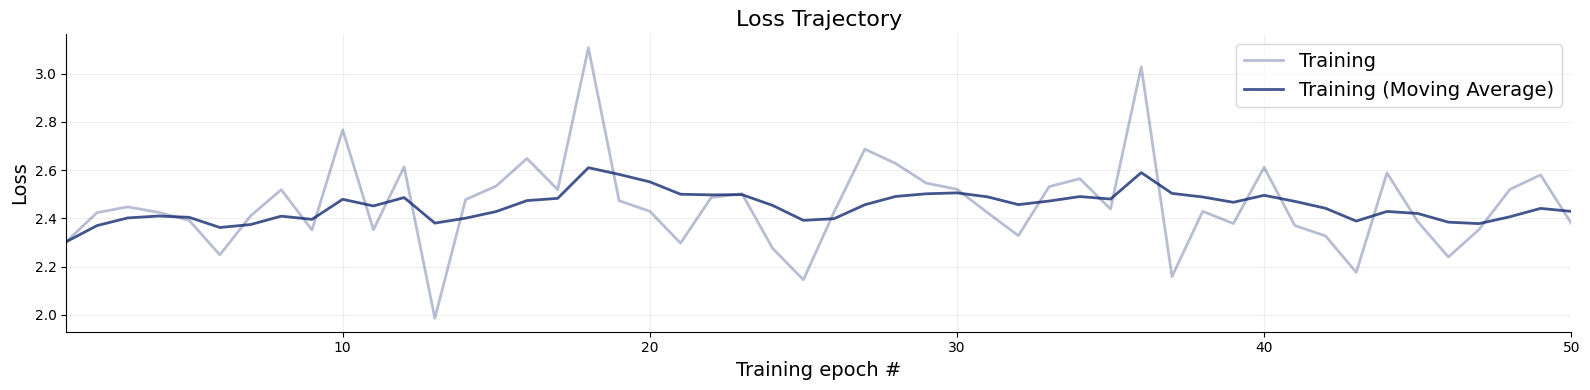

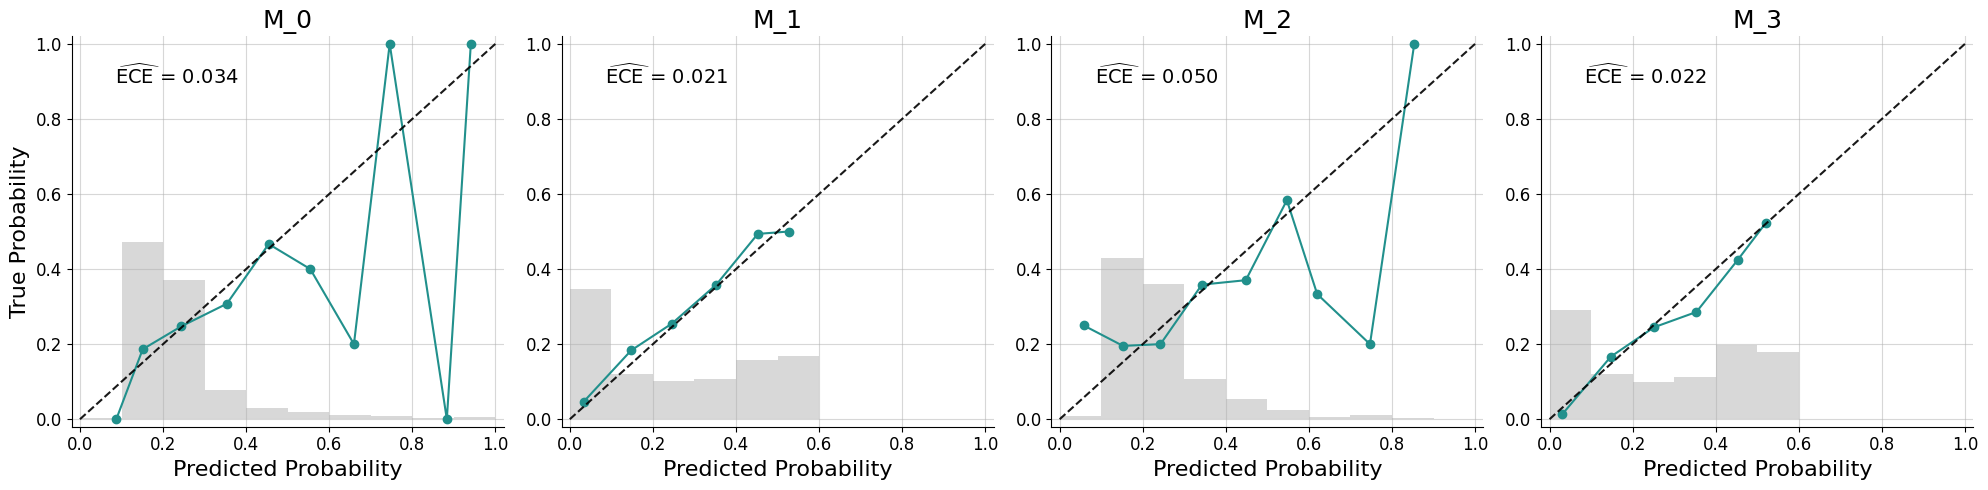

INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol M from STIXNonUnicode


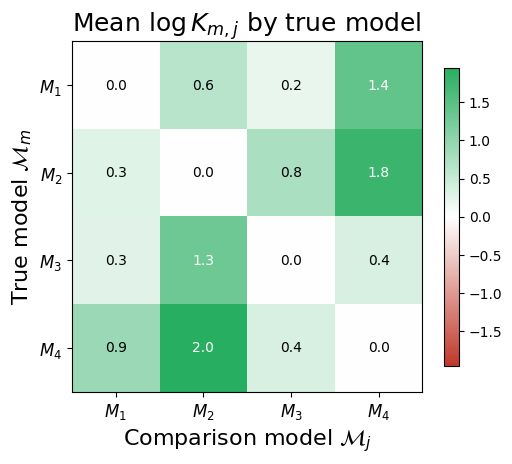

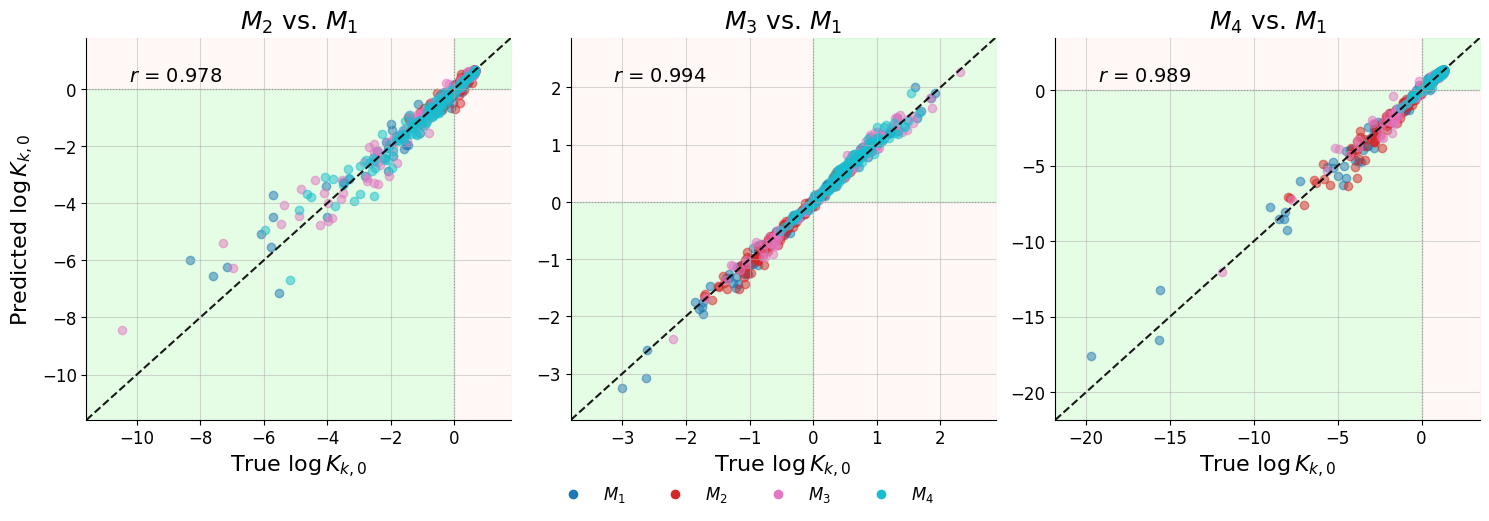

In [12]:
figures = workflow.plot_default_diagnostics(test_data=500, true_log_bfs_fn=compute_true_log_bfs)

Because we supplied `true_log_bfs_fn`, the workflow produces four diagnostic plots for BF rules:

- **Calibration curves** — reliability diagrams that assess whether the PMPs derived from the network's log BFs are trustworthy as probability estimates. Each panel bins the predicted PMP $\hat{P}(\mathcal{M}_k \mid \mathbf{x})$ on the x-axis and shows the empirical fraction of datasets in that bin that truly came from $\mathcal{M}_k$ on the y-axis; the ECE is the weighted mean absolute deviation from the diagonal. A well-calibrated network tracks the diagonal closely; curves bowing above indicate underconfidence, curves bowing below indicate overconfidence — and either can occur independently of how sharp the BF recovery looks.

- **Bayes factor recovery** — scatter plot of predicted $\log K_{k,0}$ against the analytic truth, coloured by the true generating model. Points should cluster tightly around the diagonal. The Pearson correlation $r$ annotated on each panel quantifies recovery quality; values close to 1 indicate the network tracks the analytic BF accurately across the full range.

- **Pairwise log Bayes factors** — heatmap of the mean $\log K_{m,j}$ stratified by true model. Each row $m$ shows the average predicted log BF favouring model $m$ over each competitor $j$, averaged over all test datasets truly generated from $\mathcal{M}_m$. Diagonal entries are zero by construction ($K_{m,m} = 1$); a well-trained network produces large positive off-diagonal entries in every row, confirming that the predicted evidence consistently favours the correct model over alternatives.

### PMP diagnostics

Because log Bayes factors uniquely determine posterior model probabilities under a uniform model prior, the conversion is lossless: `estimate()["model_probs"]` applies a softmax over the full pairwise BF matrix to recover PMPs. This means the confusion matrix — normally associated with PMP rules — is equally valid for a BF-trained network, and provides a complementary view of decision quality that the BF diagnostics alone do not capture.

The **confusion matrix** shows, for each true generating model, how often the network's top prediction (argmax of the PMPs) agrees with it. Rows are the true model, columns are the predicted model, and diagonal mass indicates correct classification; off-diagonal entries tend to accumulate between structurally similar model pairs.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 0.05 seconds.


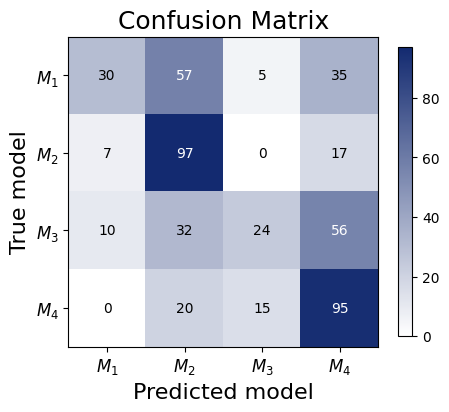

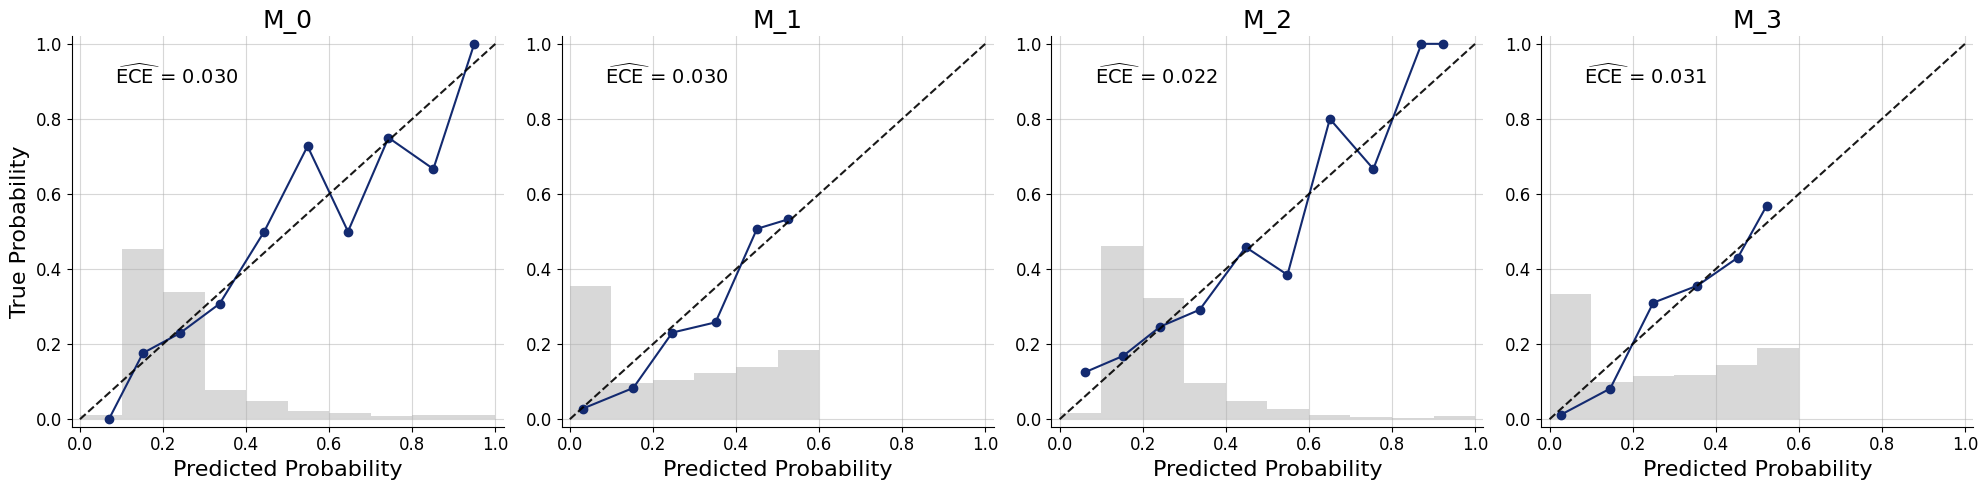

In [63]:
test_data = workflow.simulate(500)
estimates = workflow.estimate(conditions=test_data)

fig_cm = bf_plots.mc_confusion_matrix(
    pred_models=estimates["model_probs"],
    true_models=test_data["model_indices"],
)

fig_cal = bf_plots.mc_calibration(
    pred_models=estimates["model_probs"],
    true_models=test_data["model_indices"],
)

## Real-World Example: GARCH Volatility Models

The normal-normal example gave us a clean sandbox — conjugate structure, closed-form ground truth, fully controlled discrimination difficulty. But the central premise of amortized inference is that the Bayesian workflow can also be applied to intractable likelihoods. Our second example trades all of that for realism.

We now discriminate between four models from the **GARCH family**, the workhorse of volatility modelling in computational finance. All four share the same return-generating mechanism but differ in how they model the evolution of conditional variance: one captures only short-memory shocks (ARCH), one adds persistent volatility clustering (GARCH), one introduces an asymmetric leverage effect (GJR-GARCH), and one allows for heavy-tailed innovations (GARCH-t). These are genuinely hard to tell apart from a finite return series — they are nested or near-nested, and the distinguishing features manifest most clearly under extreme market conditions.

Because marginal likelihoods are not available in closed form for GARCH models, **Bayes factors cannot be computed analytically** and recovering them numerically is expensive. This makes the GARCH example a natural home for the **PMP scoring rules**: rather than estimating evidence ratios, the network learns to assign posterior model probabilities directly — exactly the quantity needed to decide which model best describes a given return series.

### Simulators

The four models form a progression of increasing complexity, each adding one structural feature: volatility persistence, an asymmetric leverage effect, and heavy-tailed innovations.

| Model | Key feature |
|-------|-------------|
| ARCH(1) | Short-memory ARCH: volatility shocks decay in one step |
| GARCH(1,1) | Persistent volatility clustering, Gaussian innovations |
| GJR-GARCH(1,1) | Leverage effect: negative shocks inflate variance more |
| GARCH-t | GARCH(1,1) with Student-t innovations; heavier tails |

Here, we unify them into a single simulator that renders their output through varying prior configurations.

In [64]:
@njit
def simulate_garch(omega, alpha, mu, beta, gamma, nu, T, burn_in):
    """JIT-compiled GARCH recursion. nu=inf selects Gaussian innovations."""
    T_total = T + burn_in
    returns = np.empty(T_total)
    eps = 0.0
    sigma2 = omega / max(1.0 - alpha - gamma * 0.5 - beta, 1e-6)
    use_gaussian = np.isinf(nu)

    for t in range(T_total):
        I_neg = 1.0 if eps < 0.0 else 0.0
        sigma2 = omega + (alpha + gamma * I_neg) * eps * eps + beta * sigma2
        if sigma2 < 1e-10:
            sigma2 = 1e-10
        elif sigma2 > 1.0:
            sigma2 = 1.0
        if use_gaussian:
            z = np.random.randn()
        else:
            z = np.random.standard_t(nu) * np.sqrt((nu - 2.0) / nu)
        eps = np.sqrt(sigma2) * z
        returns[t] = mu + eps

    out = returns[burn_in:].copy()
    for i in range(len(out)):
        if out[i] < -1.0:
            out[i] = -1.0
        elif out[i] > 1.0:
            out[i] = 1.0
    return out


def garch_model(omega, alpha, mu, beta=0.0, gamma=0.0, nu=None, T=500, burn_in=50, **kwargs):
    """Shared GARCH model for all variants.

    beta=0, gamma=0, nu=None/inf  →  ARCH(1)
    gamma=0, nu=None/inf          →  GARCH(1,1)
    nu=None/inf                   →  GJR-GARCH(1,1)
    nu provided and finite        →  GARCH-t (Student-t innovations scaled to unit variance)
    """
    nu_val = np.inf if (nu is None or np.isinf(float(nu))) else float(nu)
    out = simulate_garch(float(omega), float(alpha), float(mu),
                      float(beta), float(gamma), nu_val, T, burn_in)
    return {"returns": out[:, np.newaxis].astype(np.float32)}


# Warm up both JIT branches (Gaussian and Student-t) to pay compile cost once.
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, np.inf, 60, 10)
simulate_garch(1e-5, 0.1, 0.0, 0.8, 0.0, 5.0,    60, 10)
print("JIT warmup complete.")

JIT warmup complete.


Each model is defined by a prior function that draws parameters, with all four sharing a single likelihood that runs the GARCH recursion. `bf.make_simulator` chains them so the prior's output dict is forwarded automatically as keyword arguments to the likelihood. The unified likelihood covers all four variants via its optional parameters:

| Model | `beta` | `gamma` | `nu` |
|-------|--------|---------|------|
| ARCH(1) | 0 (default) | 0 (default) | None (default) |
| GARCH(1,1) | sampled | 0 (default) | None (default) |
| GJR-GARCH(1,1) | sampled | sampled | None (default) |
| GARCH-t | sampled | 0 (default) | sampled |

In [66]:
def arch_prior():
    return dict(
        omega=rng.uniform(5e-5, 2e-4),
        alpha=rng.uniform(0.15, 0.45),   # high α, no β — strong short-memory effect; α < 1 ensures stationarity
        beta =0.0,
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garch_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # very high persistence; clear gap above GJR's β; α + β ≤ 0.99
        gamma=0.0,
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def gjr_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        gamma=rng.uniform(0.10, 0.16),   # α + γ/2 + β ≤ 0.99; β sits clearly between ARCH (0) and GARCH (0.91+)
        beta =rng.uniform(0.83, 0.88),
        nu   =np.inf,
        mu   =rng.uniform(-5e-4, 5e-4),
    )


def garcht_prior():
    return dict(
        omega=rng.uniform(1e-6, 5e-5),
        alpha=rng.uniform(0.01, 0.03),
        beta =rng.uniform(0.91, 0.96),   # mirrors GARCH persistence; α + β ≤ 0.99
        gamma=0.0,
        nu   =rng.uniform(2.5, 4.5),     # ν > 2 ensures finite variance; entire range has distinctly heavy tails
        mu   =rng.uniform(-5e-4, 5e-4),
    )

In [67]:
arch_simulator      = bf.make_simulator([arch_prior, garch_model])
garch_simulator     = bf.make_simulator([garch_prior, garch_model])
gjr_simulator       = bf.make_simulator([gjr_prior, garch_model])
garcht_simulator    = bf.make_simulator([garcht_prior, garch_model])

simulators = [arch_simulator, garch_simulator, gjr_simulator, garcht_simulator]
model_names = ["ARCH", "GARCH", "GJR", "GARCH-t"]

### Prior predictive check

A single draw from each simulator illustrates what the network is up against. The series look deceptively similar — yet their statistical fingerprints are distinct enough for a well-trained network to tell them apart reliably.

### Setting up the adapter

The adapter for the GARCH example follows the same pattern: route `model_indices` to `inference_variables` and the return series to `summary_variables`. As before, passing `summary_variables="returns"` to `ModelComparisonWorkflow` would produce the same adapter automatically.

In [68]:
garch_adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate("model_indices", into="inference_variables")
    .concatenate(["returns"], into="summary_variables")
)

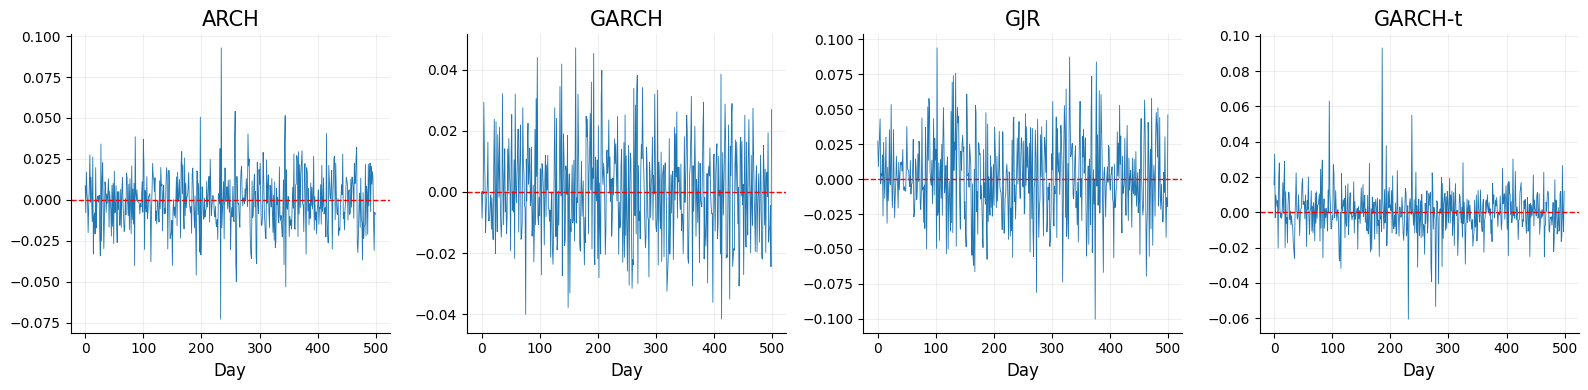

In [69]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=False)
for ax, sim, name in zip(axes, simulators, model_names):
    path = sim.sample((5,))["returns"][4, :]
    sns.lineplot(path, linewidth=0.6, ax=ax, legend=False)
    ax.grid(alpha=0.2)
    ax.set_title(name, fontsize=15)
    ax.set_xlabel("Day", fontsize=12)
    ax.axhline(0, color="red", linewidth=1, linestyle="--")
    sns.despine()
plt.tight_layout()

### PMP Scoring Rules

As motivated above, the absence of closed-form marginal likelihoods makes PMP rules the natural choice here. We also switch the summary network to a `TimeSeriesTransformer`, which is better suited to sequential data than the set-based architecture used in the simple example. We train with the default `CrossEntropyScore`; swapping in `BrierScore()` or `PolynomialScore(alpha=3.0)` requires no other changes to the workflow.

In [70]:
pmp_workflow = ModelComparisonWorkflow(
    simulator=simulators,
    adapter=garch_adapter,
    summary_network="time_series_transformer",
    model_names=model_names,
    scoring_rules=CrossEntropyScore(),
    standardize=["summary_variables"],
)

In [71]:
history = pmp_workflow.fit_online(
    epochs=50,
    num_batches_per_epoch=150,
    batch_size=64,
)

INFO:bayesflow:Fitting on dataset instance of OnlineDataset.
INFO:bayesflow:Building on a test batch.


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - loss: 1.4651 - scoring_rule/inference_scoring_rule: 1.4651
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.4704 - scoring_rule/inference_scoring_rule: 1.4704
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 1.3069 - scoring_rule/inference_scoring_rule: 1.3069
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.3775 - scoring_rule/inference_scoring_rule: 1.3775
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 1.2092 - scoring_rule/inference_scoring_rule: 1.2092
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.2165 - scoring_rule/inference_scoring_rule: 1.2165
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 1.2554 - scoring_rule/inference_scoring_rule: 1.2554
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.9245 - scoring_rule/inference_scoring_rule: 0.9245
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.7427 - scoring_rule/infe

INFO:bayesflow:Training completed in 4.59 minutes.


### Diagnostics

`plot_default_diagnostics` works for both scoring rule families — it detects the active rule and automatically selects the appropriate plots. For the BF rules used in the simple example, that meant blind coverage, Bayes factor recovery, pairwise log BFs, and calibration curves. Here, with a PMP rule, it produces a loss curve, a confusion matrix, and calibration curves.

The confusion matrix reflects the structural relationships between the models. ARCH(1) is typically the easiest to identify — its zero persistence parameter produces a qualitatively different volatility profile. The hardest pair is GARCH vs GARCH-t: both share the same variance recursion and differ only in the innovation distribution, so distinguishing them requires detecting subtle tail differences accumulated over many time steps. Some confusion between GJR and GARCH is also expected, since the leverage effect is most visible during large negative returns.

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

INFO:bayesflow:Estimation completed in 11.00 seconds.


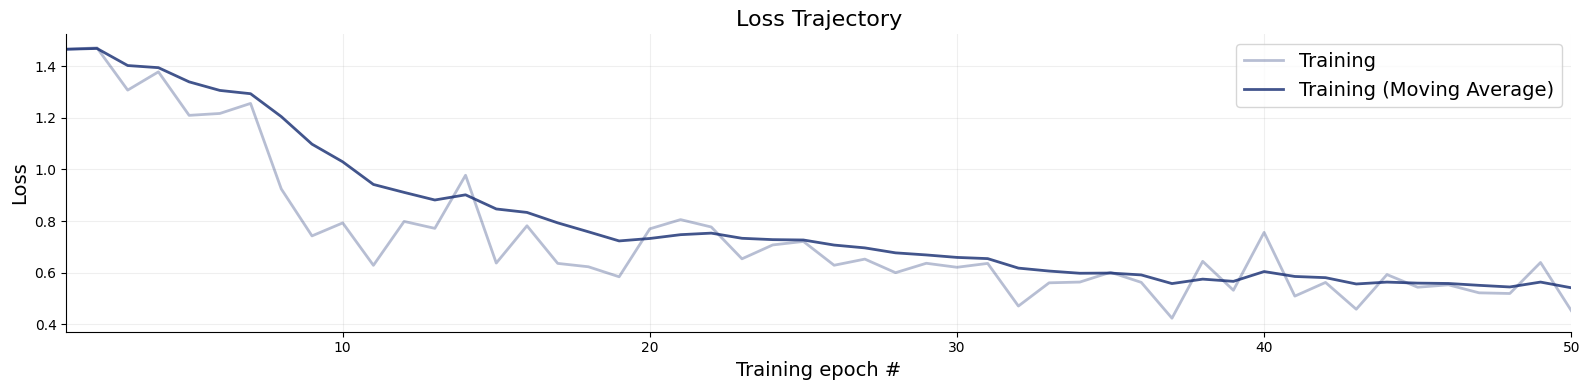

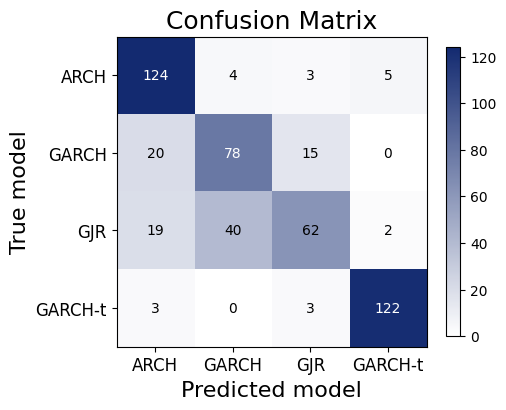

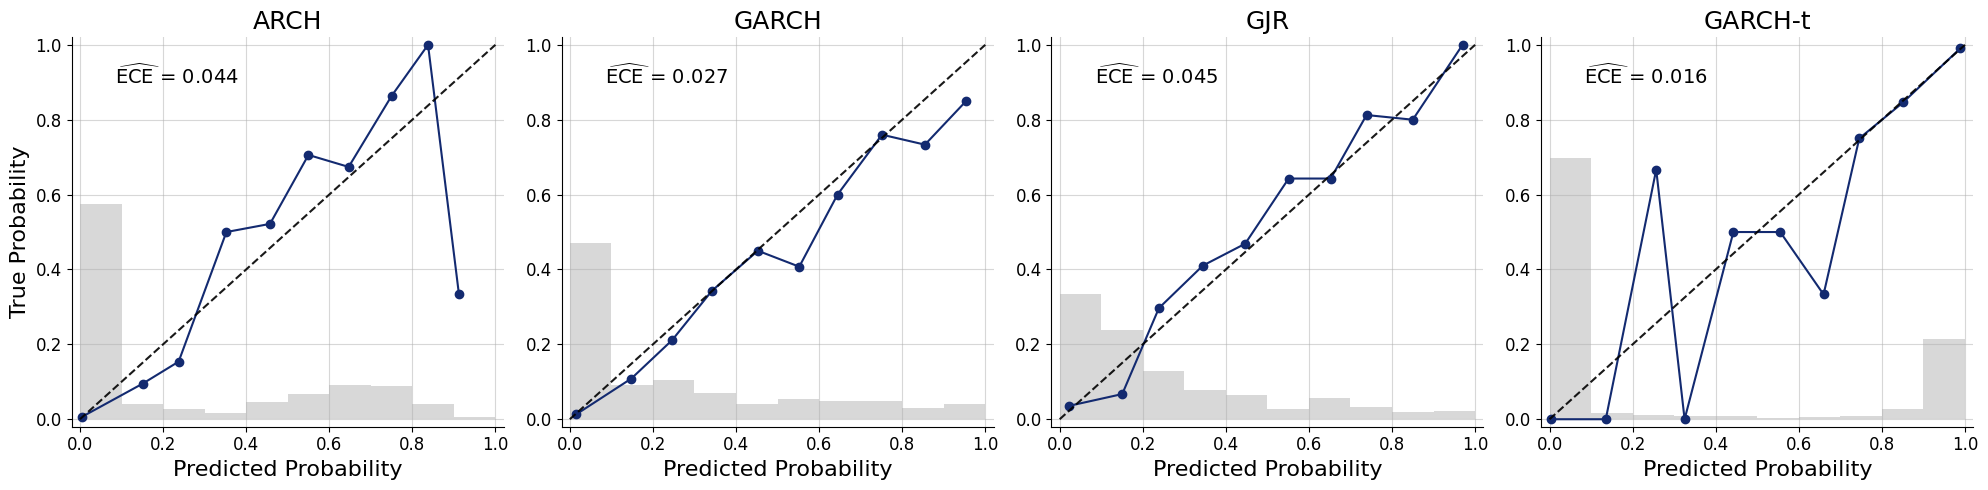

In [72]:
figures = pmp_workflow.plot_default_diagnostics(test_data=500)

Congratulations! Through this deep-dive notebook, you have seen everything that BayesFlow's `ModelComparisonWorkflow` has to offer. Now, go ahead and compare your models!